# Prediction-Ready Best-Execution Dataset

This notebook builds a model-ready dataset from the repo's real multi-venue market data. It keeps the exchange prices, pool fees, pairwise spread context, and, when available, swap/state features so a separate prediction model can be attached later without rebuilding the market plumbing.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from prediction_execution import (
    DEFAULT_HORIZONS_HOURS,
    available_market_catalog,
    export_prediction_ready_bundle,
    prepare_prediction_ready_bundle,
)

plt.style.use('default')

MARKET_SLUG = 'optimism_wbtc_weth'
HORIZONS_HOURS = DEFAULT_HORIZONS_HOURS

market_catalog = available_market_catalog(PROJECT_ROOT)
bundle = prepare_prediction_ready_bundle(PROJECT_ROOT, MARKET_SLUG, horizons_hours=HORIZONS_HOURS)
exported_paths = export_prediction_ready_bundle(bundle, horizons_hours=HORIZONS_HOURS)

venue_panel = bundle['venue_panel'].copy()
execution_summary = bundle['execution_summary'].copy()
model_frame = bundle['model_frame'].copy()
prediction_template = bundle['prediction_template'].copy()
manifest = bundle['manifest']

summary_rows = [
    {'field': 'market_slug', 'value': MARKET_SLUG},
    {'field': 'window_start_utc', 'value': execution_summary['timestamp'].min()},
    {'field': 'window_end_utc', 'value': execution_summary['timestamp'].max()},
    {'field': 'venue_count', 'value': int(venue_panel['pair_address'].nunique())},
    {'field': 'hourly_rows', 'value': int(len(execution_summary))},
    {'field': 'has_pairwise_edges', 'value': not bundle['pairwise_edges'].empty},
    {'field': 'has_swaps_raw', 'value': not bundle['swaps_raw'].empty},
    {'field': 'has_pool_state_1s', 'value': not bundle['pool_state_1s'].empty},
    {'field': 'prediction_template', 'value': str(exported_paths['prediction_template'])},
    {'field': 'model_frame', 'value': str(exported_paths['model_frame'])},
]

display(pd.DataFrame(summary_rows))
display(Markdown('## Available Markets'))
display(market_catalog.sort_values(['venues', 'market_slug'], ascending=[False, True]).reset_index(drop=True))
display(Markdown('## Venue Overview'))
venue_overview = venue_panel[[
    'venue_label', 'dex_id', 'pool_name', 'pair_address', 'pool_fee_bps', 'fee_known', 'selected_for_dataset'
]].drop_duplicates().sort_values('venue_label').reset_index(drop=True)
display(venue_overview)

,field,value
0,market_slug,optimism_wbtc_weth
1,window_start_utc,2026-03-16 08:00:00+00:00
2,window_end_utc,2026-04-15 07:00:00+00:00
3,venue_count,3
4,hourly_rows,720
5,has_pairwise_edges,True
6,has_swaps_raw,True
7,has_pool_state_1s,True
8,prediction_template,/Users/bilguuntsolmon/Desktop/main/uni/finance...
9,model_frame,/Users/bilguuntsolmon/Desktop/main/uni/finance...


## Available Markets

,market_slug,hourly_rows,venues,window_start_utc,window_end_utc,has_pairwise_edges,has_swaps_raw,has_pool_state_1s,has_manifest
0,arbitrum_wbtc_weth,2160,3,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,True,True,True
1,cosmos_research,2160,3,2026-03-15 21:00:00+00:00,2026-04-15 07:00:00+00:00,True,True,True,True
2,mainnet_usdc_usdt,2160,3,2026-03-16 02:00:00+00:00,2026-04-15 07:00:00+00:00,True,False,False,True
3,mainnet_wbtc_usdc,2160,3,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,False,False,True
4,mainnet_weth_usdc,2160,3,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,False,False,True
5,optimism_wbtc_weth,2160,3,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,True,True,True
6,solana_research,2160,3,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,False,True,True
7,base_wbtc_weth,1440,2,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,False,False,True
8,mainnet_dai_usdc,1440,2,2026-03-16 08:00:00+00:00,2026-04-15 07:00:00+00:00,True,False,False,True


## Venue Overview

,venue_label,dex_id,pool_name,pair_address,pool_fee_bps,fee_known,selected_for_dataset
0,sushiswap-v3-optimism | WETH / WBTC 0.3%,sushiswap-v3-optimism,WETH / WBTC 0.3%,0x689a850f62b41d89b5e5c3465cd291374b215813,30.0,True,True
1,uniswap_v3_optimism | WETH / WBTC 0.3%,uniswap_v3_optimism,WETH / WBTC 0.3%,0x73b14a78a0d396c521f954532d43fd5ffe385216,30.0,True,True
2,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream,WETH / WBTC 0.05%,0x319c0dd36284ac24a6b2bee73929f699b9f48c38,5.0,True,True


In [2]:
display(Markdown('## Best-Execution Summary'))
summary_columns = [
    'timestamp', 'reference_price_usd', 'best_buy_venue', 'best_buy_effective_price_usd',
    'best_sell_venue', 'best_sell_effective_price_usd', 'cross_exchange_dispersion_bps',
    'best_cross_exchange_edge_bps', 'best_buy_gap_vs_second_bps', 'best_sell_gap_vs_second_bps'
]
display(execution_summary.loc[:, summary_columns].head(25))

display(Markdown('## Model-Ready Feature Preview'))
preview_columns = [
    'timestamp', 'reference_price_usd', 'cross_exchange_dispersion_bps', 'best_buy_venue', 'best_sell_venue',
    'reference_return_1h_bps', 'reference_return_4h_bps', 'reference_volatility_24h_bps',
    'target_future_return_1h_bps', 'target_future_return_4h_bps', 'target_future_return_24h_bps'
]
display(model_frame.loc[:, [c for c in preview_columns if c in model_frame.columns]].head(25))

display(Markdown('## Prediction Template Your Teammate Can Fill'))
display(prediction_template.head(25))

feature_groups = pd.DataFrame({
    'group': ['execution_summary', 'venue_wide_features', 'targets'],
    'count': [
        int(sum('__' not in col and not col.startswith('target_') for col in model_frame.columns)),
        int(sum('__' in col for col in model_frame.columns)),
        int(sum(col.startswith('target_') for col in model_frame.columns)),
    ],
})
display(Markdown('## Model Frame Layout'))
display(feature_groups)

## Best-Execution Summary

,timestamp,reference_price_usd,best_buy_venue,best_buy_effective_price_usd,best_sell_venue,best_sell_effective_price_usd,cross_exchange_dispersion_bps,best_cross_exchange_edge_bps,best_buy_gap_vs_second_bps,best_sell_gap_vs_second_bps
0,2026-03-16 08:00:00+00:00,73040.433159,velodrome-finance-slipstream | WETH / WBTC 0.05%,73026.072128,uniswap_v3_optimism | WETH / WBTC 0.3%,73070.091004,41.154307,6.027830,31.972462,16.038863
1,2026-03-16 09:00:00+00:00,72946.410259,velodrome-finance-slipstream | WETH / WBTC 0.05%,73129.524021,velodrome-finance-slipstream | WETH / WBTC 0.05%,73056.431043,21.905174,-9.995002,3.075595,45.218067
2,2026-03-16 10:00:00+00:00,73143.226625,uniswap_v3_optimism | WETH / WBTC 0.3%,73262.594075,velodrome-finance-slipstream | WETH / WBTC 0.05%,73501.732289,67.773053,32.641243,13.658024,79.251955
3,2026-03-16 11:00:00+00:00,73143.226625,uniswap_v3_optimism | WETH / WBTC 0.3%,73262.594075,velodrome-finance-slipstream | WETH / WBTC 0.05%,73371.639101,49.953763,14.884134,13.658024,61.412347
4,2026-03-16 12:00:00+00:00,73615.972399,velodrome-finance-slipstream | WETH / WBTC 0.05%,73652.585656,velodrome-finance-slipstream | WETH / WBTC 0.05%,73578.969878,2.640838,-9.995002,25.014011,22.428465
5,2026-03-16 13:00:00+00:00,74020.340399,velodrome-finance-slipstream | WETH / WBTC 0.05%,73807.819162,uniswap_v3_optimism | WETH / WBTC 0.3%,73799.277865,33.944019,-1.157235,58.880246,0.135300
6,2026-03-16 14:00:00+00:00,73222.198186,sushiswap-v3-optimism | WETH / WBTC 0.3%,73220.004610,velodrome-finance-slipstream | WETH / WBTC 0.05%,73238.699033,37.579635,2.553185,12.560742,32.350582
7,2026-03-16 15:00:00+00:00,73214.197578,velodrome-finance-slipstream | WETH / WBTC 0.05%,73191.466017,velodrome-finance-slipstream | WETH / WBTC 0.05%,73118.311128,9.470994,-9.995002,33.115084,15.589467
8,2026-03-16 16:00:00+00:00,73583.447805,velodrome-finance-slipstream | WETH / WBTC 0.05%,73645.076177,velodrome-finance-slipstream | WETH / WBTC 0.05%,73571.467905,7.079719,-9.995002,17.895118,28.457302
9,2026-03-16 17:00:00+00:00,73697.630365,velodrome-finance-slipstream | WETH / WBTC 0.05%,73767.287806,velodrome-finance-slipstream | WETH / WBTC 0.05%,73693.557384,6.811540,-9.995002,18.163594,29.535947


## Model-Ready Feature Preview

,timestamp,reference_price_usd,cross_exchange_dispersion_bps,best_buy_venue,best_sell_venue,reference_return_1h_bps,reference_return_4h_bps,reference_volatility_24h_bps,target_future_return_1h_bps,target_future_return_4h_bps,target_future_return_24h_bps
0,2026-03-16 08:00:00+00:00,73040.433159,41.154307,velodrome-finance-slipstream | WETH / WBTC 0.05%,uniswap_v3_optimism | WETH / WBTC 0.3%,NaN,NaN,NaN,-12.872719,78.797348,163.077241
1,2026-03-16 09:00:00+00:00,72946.410259,21.905174,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,-12.872719,NaN,NaN,26.980953,147.221794,125.478879
2,2026-03-16 10:00:00+00:00,73143.226625,67.773053,uniswap_v3_optimism | WETH / WBTC 0.3%,velodrome-finance-slipstream | WETH / WBTC 0.05%,26.980953,NaN,NaN,0.000000,10.796839,57.542805
3,2026-03-16 11:00:00+00:00,73143.226625,49.953763,uniswap_v3_optimism | WETH / WBTC 0.3%,velodrome-finance-slipstream | WETH / WBTC 0.05%,0.000000,NaN,NaN,64.632885,9.703011,83.602114
4,2026-03-16 12:00:00+00:00,73615.972399,2.640838,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,64.632885,78.797348,34.259050,54.929384,-4.418144,13.231167
5,2026-03-16 13:00:00+00:00,74020.340399,33.944019,velodrome-finance-slipstream | WETH / WBTC 0.05%,uniswap_v3_optimism | WETH / WBTC 0.3%,54.929384,147.221794,33.596001,-107.827417,-43.597480,-101.512104
6,2026-03-16 14:00:00+00:00,73222.198186,37.579635,sushiswap-v3-optimism | WETH / WBTC 0.3%,velodrome-finance-slipstream | WETH / WBTC 0.05%,-107.827417,10.796839,62.615919,-1.092648,106.324267,128.893534
7,2026-03-16 15:00:00+00:00,73214.197578,9.470994,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,-1.092648,9.703011,57.196677,50.434238,69.774185,80.237898
8,2026-03-16 16:00:00+00:00,73583.447805,7.079719,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,50.434238,-4.418144,55.489113,15.517425,49.278123,51.454504
9,2026-03-16 17:00:00+00:00,73697.630365,6.811540,velodrome-finance-slipstream | WETH / WBTC 0.05%,velodrome-finance-slipstream | WETH / WBTC 0.05%,15.517425,-43.597480,51.945377,41.127167,52.555673,55.117285


## Prediction Template Your Teammate Can Fill

,timestamp,market_slug,reference_price_usd,predicted_return_1h_bps,predicted_price_1h,predicted_return_4h_bps,predicted_price_4h,predicted_return_24h_bps,predicted_price_24h,prediction_source,prediction_notes
0,2026-03-16 08:00:00+00:00,optimism_wbtc_weth,73040.433159,NaN,NaN,NaN,NaN,NaN,NaN,,
1,2026-03-16 09:00:00+00:00,optimism_wbtc_weth,72946.410259,NaN,NaN,NaN,NaN,NaN,NaN,,
2,2026-03-16 10:00:00+00:00,optimism_wbtc_weth,73143.226625,NaN,NaN,NaN,NaN,NaN,NaN,,
3,2026-03-16 11:00:00+00:00,optimism_wbtc_weth,73143.226625,NaN,NaN,NaN,NaN,NaN,NaN,,
4,2026-03-16 12:00:00+00:00,optimism_wbtc_weth,73615.972399,NaN,NaN,NaN,NaN,NaN,NaN,,
5,2026-03-16 13:00:00+00:00,optimism_wbtc_weth,74020.340399,NaN,NaN,NaN,NaN,NaN,NaN,,
6,2026-03-16 14:00:00+00:00,optimism_wbtc_weth,73222.198186,NaN,NaN,NaN,NaN,NaN,NaN,,
7,2026-03-16 15:00:00+00:00,optimism_wbtc_weth,73214.197578,NaN,NaN,NaN,NaN,NaN,NaN,,
8,2026-03-16 16:00:00+00:00,optimism_wbtc_weth,73583.447805,NaN,NaN,NaN,NaN,NaN,NaN,,
9,2026-03-16 17:00:00+00:00,optimism_wbtc_weth,73697.630365,NaN,NaN,NaN,NaN,NaN,NaN,,


## Model Frame Layout

,group,count
0,execution_summary,44
1,venue_wide_features,81
2,targets,12


## Visual Diagnostics

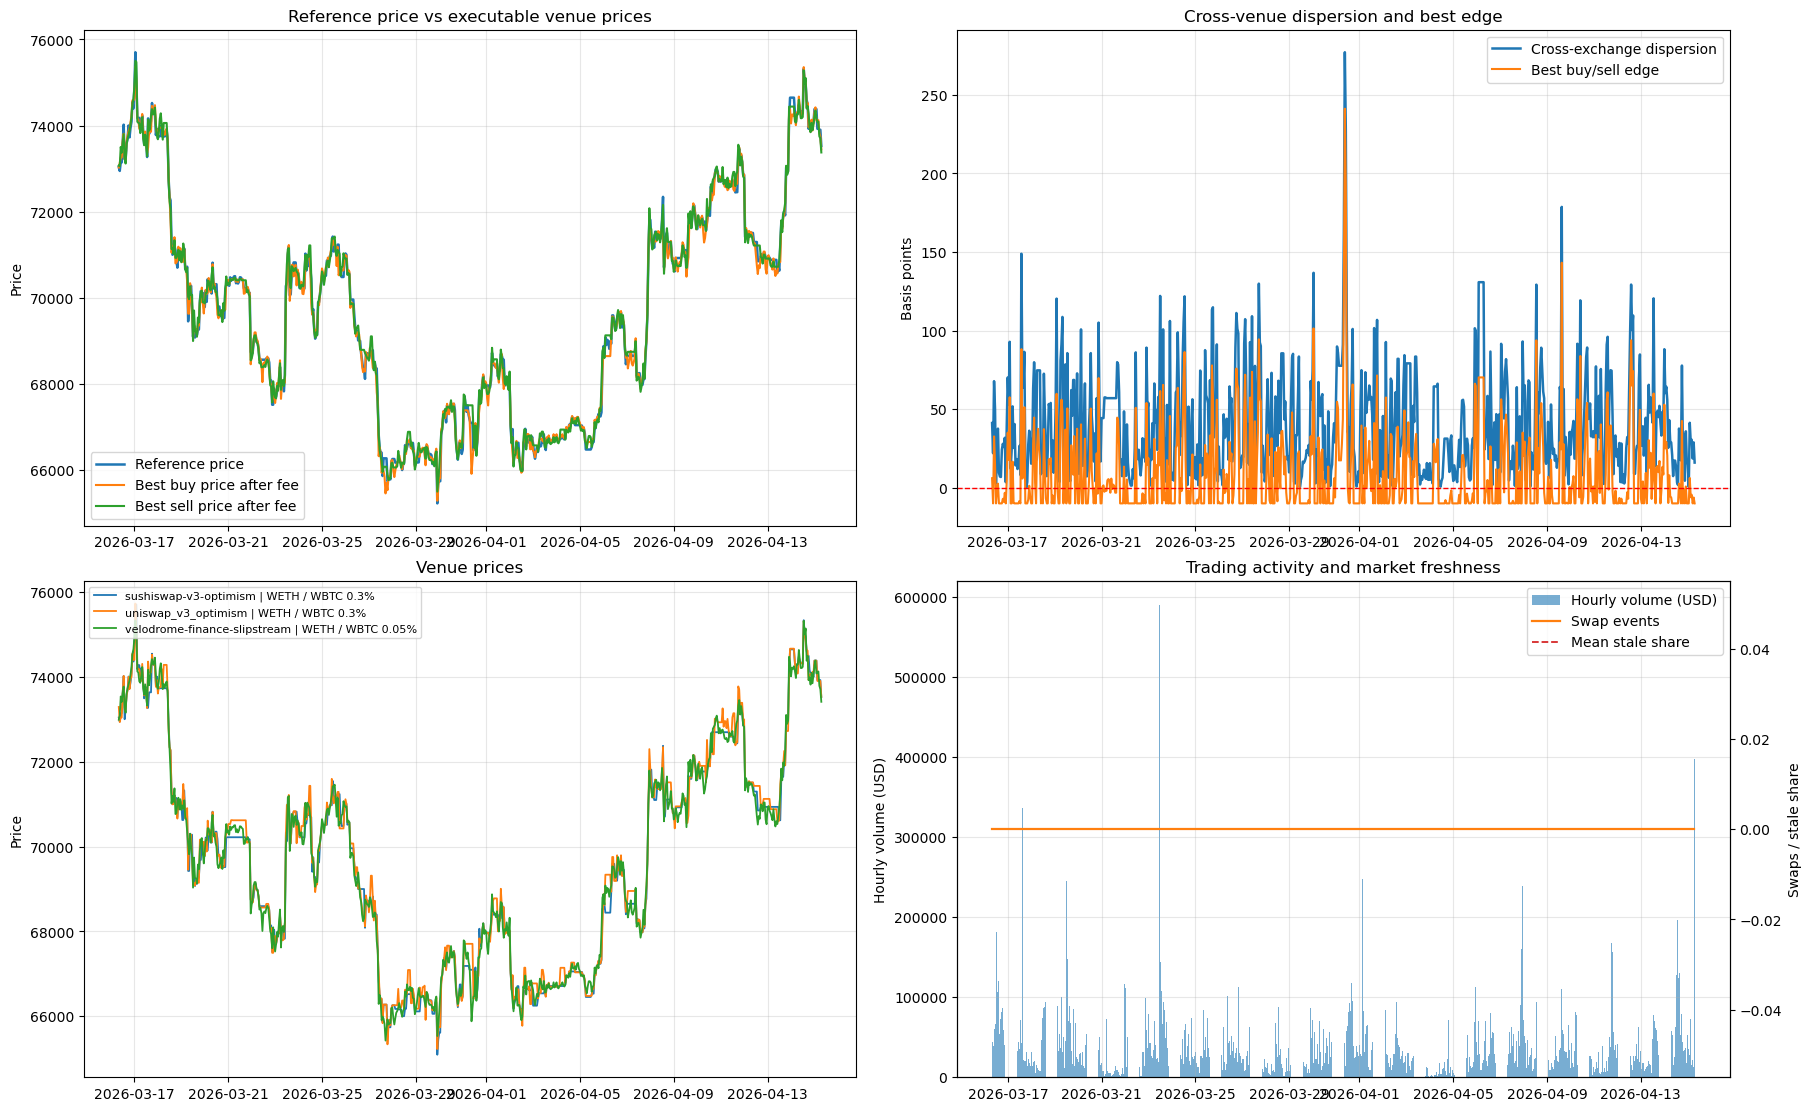

In [3]:
display(Markdown('## Visual Diagnostics'))

ops = execution_summary.copy().sort_values('timestamp').reset_index(drop=True)
venue_prices = venue_panel[['timestamp', 'venue_label', 'close_usd']].dropna().copy()
hourly_ops = venue_panel.copy()
for column in ['swap_events', 'stale_share']:
    if column not in hourly_ops.columns:
        hourly_ops[column] = np.nan
hourly_ops = (
    hourly_ops.groupby('timestamp', as_index=False)
    .agg(
        total_hourly_volume_usd=('volume_usd', 'sum'),
        total_swap_events=('swap_events', 'sum'),
        mean_stale_share=('stale_share', 'mean'),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)

axes[0, 0].plot(ops['timestamp'], ops['reference_price_usd'], linewidth=1.8, label='Reference price')
axes[0, 0].plot(ops['timestamp'], ops['best_buy_effective_price_usd'], linewidth=1.5, label='Best buy price after fee')
axes[0, 0].plot(ops['timestamp'], ops['best_sell_effective_price_usd'], linewidth=1.5, label='Best sell price after fee')
axes[0, 0].set_title('Reference price vs executable venue prices')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(ops['timestamp'], ops['cross_exchange_dispersion_bps'], linewidth=1.8, label='Cross-exchange dispersion')
axes[0, 1].plot(ops['timestamp'], ops['best_cross_exchange_edge_bps'], linewidth=1.5, label='Best buy/sell edge')
axes[0, 1].axhline(0.0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Cross-venue dispersion and best edge')
axes[0, 1].set_ylabel('Basis points')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

for venue, group in venue_prices.groupby('venue_label'):
    axes[1, 0].plot(group['timestamp'], group['close_usd'], linewidth=1.3, label=venue)
axes[1, 0].set_title('Venue prices')
axes[1, 0].set_ylabel('Price')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(loc='upper left', fontsize=8)

axes[1, 1].bar(hourly_ops['timestamp'], hourly_ops['total_hourly_volume_usd'], width=0.03, alpha=0.6, label='Hourly volume (USD)')
swap_ax = axes[1, 1].twinx()
swap_ax.plot(hourly_ops['timestamp'], hourly_ops['total_swap_events'], color='tab:orange', linewidth=1.6, label='Swap events')
swap_ax.plot(hourly_ops['timestamp'], hourly_ops['mean_stale_share'], color='tab:red', linewidth=1.3, linestyle='--', label='Mean stale share')
axes[1, 1].set_title('Trading activity and market freshness')
axes[1, 1].set_ylabel('Hourly volume (USD)')
swap_ax.set_ylabel('Swaps / stale share')
axes[1, 1].grid(alpha=0.3)
lines_a, labels_a = axes[1, 1].get_legend_handles_labels()
lines_b, labels_b = swap_ax.get_legend_handles_labels()
axes[1, 1].legend(lines_a + lines_b, labels_a + labels_b, loc='upper right')

plt.show()

In [4]:
display(Markdown('## Exported Files'))
export_rows = [{'artifact': key, 'path': str(path)} for key, path in exported_paths.items()]
display(pd.DataFrame(export_rows))

display(Markdown(
    'The `model_frame` is the file your teammate can train on. The `predictions_input_template.csv` '
    'is the file they can fill with predicted returns or predicted prices and hand back to the router notebook.'
))

## Exported Files

,artifact,path
0,venue_panel,/Users/bilguuntsolmon/Desktop/main/uni/finance...
1,execution_summary,/Users/bilguuntsolmon/Desktop/main/uni/finance...
2,model_frame,/Users/bilguuntsolmon/Desktop/main/uni/finance...
3,prediction_template,/Users/bilguuntsolmon/Desktop/main/uni/finance...
4,metadata,/Users/bilguuntsolmon/Desktop/main/uni/finance...


The `model_frame` is the file your teammate can train on. The `predictions_input_template.csv` is the file they can fill with predicted returns or predicted prices and hand back to the router notebook.